# 🎙️ Microphone Array Beamforming Simulator
**Supports:** Rectangular · Circular · Hexagonal arrays  
**Steering:** Auto phase-shift (Delay-and-Sum)  
**Outputs:** Polar · Cartesian dB · 2D Heatmap · 3D Surface

In [7]:
# ── Install deps if needed ──────────────────────────────────────────────────
# !pip install numpy matplotlib scipy ipywidgets plotly

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.signal.windows import chebwin, hamming
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, HBox, VBox, Layout
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print('✅ All imports successful')

✅ All imports successful


---
## 1 · Array Geometry Generator

In [8]:
def generate_array(shape: str, N: int, d: float):
    """
    Generate mic positions (in wavelengths).

    Parameters
    ----------
    shape : 'rectangular' | 'circular' | 'hexagonal'
    N     : number of elements (rectangular: approx N×N grid; others: exactly N)
    d     : element spacing in wavelengths

    Returns
    -------
    pos : ndarray, shape (M, 3)  — (x, y, z) positions
    """
    if shape == 'rectangular':
        side = int(np.ceil(np.sqrt(N)))
        xs = (np.arange(side) - (side - 1) / 2) * d
        ys = (np.arange(side) - (side - 1) / 2) * d
        xx, yy = np.meshgrid(xs, ys)
        pos = np.column_stack([xx.ravel(), yy.ravel(), np.zeros(side * side)])

    elif shape == 'circular':
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
        R = d * N / (2 * np.pi)          # radius so arc-length between mics ≈ d
        x = R * np.cos(angles)
        y = R * np.sin(angles)
        pos = np.column_stack([x, y, np.zeros(N)])

    elif shape == 'hexagonal':
        # Build concentric hexagonal rings until we have ≥ N elements
        pos_list = [(0.0, 0.0, 0.0)]
        ring = 1
        while len(pos_list) < N:
            # Walk around each ring
            dirs = [
                (1, 0), (0, 1), (-1, 1),
                (-1, 0), (0, -1), (1, -1)
            ]
            px, py = ring * d, 0.0       # start of ring (axial)
            # Convert axial to cartesian hex
            q, r = ring, 0
            x_hex = d * (3/2 * q)
            y_hex = d * (np.sqrt(3)/2 * q + np.sqrt(3) * r)
            # Simpler: enumerate all hex grid points within ring radius
            for i in range(-ring, ring + 1):
                for j in range(-ring, ring + 1):
                    if abs(i + j) <= ring:
                        x_c = d * (i + j * 0.5)
                        y_c = d * (j * np.sqrt(3) / 2)
                        pt = (round(x_c, 9), round(y_c, 9), 0.0)
                        if pt not in pos_list:
                            pos_list.append(pt)
            ring += 1
        pos = np.array(pos_list[:N])

    else:
        raise ValueError(f"Unknown shape '{shape}'. Choose rectangular, circular, or hexagonal.")

    return pos


def plot_array_geometry(pos, title='Array Geometry'):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(pos[:, 0], pos[:, 1], s=80, color='royalblue', edgecolors='k', zorder=3)
    for i, (x, y, _) in enumerate(pos):
        ax.annotate(str(i), (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=7, color='gray')
    ax.set_aspect('equal')
    ax.set_xlabel('x (λ)')
    ax.set_ylabel('y (λ)')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print('✅ Geometry functions defined')

✅ Geometry functions defined


---
## 2 · Beamforming Engine

In [9]:
def compute_steering_vector(pos, theta0_deg, phi0_deg):
    """
    Compute auto-steering weights (delay-and-sum) for direction (theta0, phi0).

    theta0 : elevation angle from boresight (degrees). 0 = boresight (z-axis).
    phi0   : azimuth angle in x-y plane (degrees).
    """
    theta0 = np.deg2rad(theta0_deg)
    phi0   = np.deg2rad(phi0_deg)

    # Unit vector in steering direction
    u = np.array([
        np.sin(theta0) * np.cos(phi0),
        np.sin(theta0) * np.sin(phi0),
        np.cos(theta0)
    ])

    # Phase shift per element: w_n = exp(-j * 2π * r_n · û)
    phases = -2 * np.pi * (pos @ u)
    weights = np.exp(1j * phases)
    return weights


def apply_window(weights, window_type='uniform'):
    """Apply amplitude taper to reduce sidelobes."""
    N = len(weights)
    if window_type == 'hamming':
        taper = hamming(N)
    elif window_type == 'chebyshev':
        taper = chebwin(N, at=40)   # 40 dB sidelobe attenuation
    else:  # uniform
        taper = np.ones(N)
    return weights * taper


def compute_beampattern(pos, weights, theta_range, phi_range):
    """
    Compute 2D beampattern over a grid of (theta, phi).

    Returns
    -------
    AF_dB : 2D array [len(phi_range), len(theta_range)] in dB (normalized to 0 dB peak)
    """
    THETA, PHI = np.meshgrid(theta_range, phi_range)

    # Direction cosines
    ux = np.sin(THETA) * np.cos(PHI)
    uy = np.sin(THETA) * np.sin(PHI)
    uz = np.cos(THETA)

    # Shape: (len_phi, len_theta, 3)
    U = np.stack([ux, uy, uz], axis=-1)

    # Phase at each element for each direction: (len_phi, len_theta, N)
    # pos: (N, 3), U: (Np, Nt, 3)
    phase = 2 * np.pi * np.einsum('ijk,lk->ijl', U, pos)

    # Array factor: sum_n w_n * exp(j * phase_n)
    AF = np.einsum('ijl,l->ij', np.exp(1j * phase), weights)

    AF_abs = np.abs(AF)
    AF_abs /= AF_abs.max()                     # Normalize
    AF_dB  = 20 * np.log10(AF_abs + 1e-12)    # to dB, avoid log(0)

    return AF_dB

print('✅ Beamforming engine defined')

✅ Beamforming engine defined


---
## 3 · Visualization Functions

In [10]:
def plot_all(pos, AF_dB, theta_range, phi_range,
             theta0_deg, phi0_deg, dynamic_range_dB=40):
    """
    Plot all 4 visualizations: Polar, Cartesian dB, 2D Heatmap, 3D Surface.
    """
    theta_deg = np.rad2deg(theta_range)
    phi_deg   = np.rad2deg(phi_range)

    # Pick azimuth slice at phi ≈ phi0 for 1D plots
    phi_idx = np.argmin(np.abs(phi_deg - phi0_deg))
    slice_1d = AF_dB[phi_idx, :]     # vs theta at steering phi

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(
        f'Beampattern  ·  Steering: θ={theta0_deg}°  φ={phi0_deg}°  ·  {len(pos)} elements',
        fontsize=14, fontweight='bold', y=0.98
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.35)

    # ── Plot 1: Polar ──────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0], polar=True)
    r_polar = np.clip(slice_1d + dynamic_range_dB, 0, dynamic_range_dB)
    ax1.plot(theta_range, r_polar, color='royalblue', lw=1.8)
    ax1.fill(theta_range, r_polar, alpha=0.15, color='royalblue')
    ax1.set_theta_zero_location('N')
    ax1.set_theta_direction(-1)
    ax1.set_rlim(0, dynamic_range_dB)
    ax1.set_rticks([10, 20, 30, 40])
    ax1.set_rlabel_position(45)
    ax1.set_title(f'Polar (φ≈{phi0_deg}° slice)', pad=12, fontsize=11)

    # ── Plot 2: Cartesian dB ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(theta_deg, slice_1d, color='crimson', lw=1.8)
    ax2.axvline(theta0_deg, color='gold', ls='--', lw=1.2, label=f'Steer θ={theta0_deg}°')
    ax2.axhline(-3, color='gray', ls=':', lw=1, label='-3 dB')
    ax2.set_ylim(-dynamic_range_dB, 3)
    ax2.set_xlabel('θ (degrees)')
    ax2.set_ylabel('AF (dB)')
    ax2.set_title(f'Cartesian dB (φ≈{phi0_deg}° slice)', fontsize=11)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.4)

    # ── Plot 3: 2D Heatmap ─────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    extent = [theta_deg.min(), theta_deg.max(), phi_deg.min(), phi_deg.max()]
    im = ax3.imshow(
        AF_dB,
        aspect='auto',
        origin='lower',
        extent=extent,
        cmap='inferno',
        vmin=-dynamic_range_dB,
        vmax=0
    )
    ax3.scatter([theta0_deg], [phi0_deg], marker='+', s=120,
                color='cyan', linewidths=2, zorder=5, label='Steering')
    ax3.set_xlabel('θ — Elevation (deg)')
    ax3.set_ylabel('φ — Azimuth (deg)')
    ax3.set_title('2D Heatmap (θ vs φ)', fontsize=11)
    ax3.legend(fontsize=8)
    plt.colorbar(im, ax=ax3, label='dB')

    # ── Plot 4: 3D Surface ─────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1], projection='3d')
    THETA_G, PHI_G = np.meshgrid(theta_range, phi_range)
    R = np.clip(AF_dB + dynamic_range_dB, 0, dynamic_range_dB) / dynamic_range_dB

    X = R * np.sin(THETA_G) * np.cos(PHI_G)
    Y = R * np.sin(THETA_G) * np.sin(PHI_G)
    Z = R * np.cos(THETA_G)

    norm = Normalize(vmin=0, vmax=1)
    ax4.plot_surface(X, Y, Z, facecolors=plt.cm.plasma(norm(R)),
                     rstride=3, cstride=3, alpha=0.9, linewidth=0)
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')
    ax4.set_title('3D Radiation Surface', fontsize=11)

    plt.savefig('/tmp/beampattern.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('💾 Saved to /tmp/beampattern.png')

print('✅ Visualization functions defined')

✅ Visualization functions defined


---
## 4 · Interactive Simulator
Use the sliders below to configure your array and steering direction in real time.

In [11]:
# ── Angular resolution ──────────────────────────────────────────────────────
theta_range = np.linspace(0,   np.pi,     180)   # 0° to 180° (elevation)
phi_range   = np.linspace(-np.pi, np.pi,  180)   # -180° to 180° (azimuth)


def run_simulation(shape, N, spacing_lambda, window,
                   theta0_deg, phi0_deg, dynamic_range_dB):
    # 1. Geometry
    pos = generate_array(shape, N, spacing_lambda)

    # 2. Weights: auto-steer
    weights = compute_steering_vector(pos, theta0_deg, phi0_deg)
    weights = apply_window(weights, window)

    # 3. Pattern
    AF_dB = compute_beampattern(pos, weights, theta_range, phi_range)

    # 4. Geometry preview
    plot_array_geometry(pos, title=f'{shape.capitalize()} Array · {len(pos)} elements · d={spacing_lambda}λ')

    # 5. All beampattern plots
    plot_all(pos, AF_dB, theta_range, phi_range,
             theta0_deg, phi0_deg, dynamic_range_dB)

    # 6. Stats
    print('─' * 50)
    print(f'  Array shape   : {shape}')
    print(f'  Elements      : {len(pos)}')
    print(f'  Spacing       : {spacing_lambda} λ')
    print(f'  Window        : {window}')
    print(f'  Steering      : θ={theta0_deg}°  φ={phi0_deg}°')
    # Rough 3 dB beamwidth from Cartesian slice
    phi_idx = np.argmin(np.abs(np.rad2deg(phi_range) - phi0_deg))
    slice_1d = AF_dB[phi_idx, :]
    mask_3dB = slice_1d >= -3
    if mask_3dB.any():
        bw = np.rad2deg(theta_range[mask_3dB][-1] - theta_range[mask_3dB][0])
        print(f'  3 dB Beamwidth: ~{bw:.1f}°')
    peak_dB = AF_dB.max()
    print(f'  Peak          : {peak_dB:.1f} dB (normalized)')
    print('─' * 50)


# ── Widget definitions ──────────────────────────────────────────────────────
style  = {'description_width': '160px'}
layout = Layout(width='500px')

w_shape   = widgets.Dropdown(
    options=['rectangular', 'circular', 'hexagonal'],
    value='hexagonal', description='Array shape:', style=style, layout=layout)

w_N       = widgets.IntSlider(
    value=19, min=4, max=64, step=1,
    description='# Elements (N):', style=style, layout=layout)

w_spacing = widgets.FloatSlider(
    value=0.5, min=0.25, max=1.0, step=0.05,
    description='Spacing (λ):', style=style, layout=layout)

w_window  = widgets.Dropdown(
    options=['uniform', 'hamming', 'chebyshev'],
    value='uniform', description='Amplitude window:', style=style, layout=layout)

w_theta0  = widgets.FloatSlider(
    value=30, min=0, max=90, step=1,
    description='Steer elevation θ₀ (°):', style=style, layout=layout)

w_phi0    = widgets.FloatSlider(
    value=45, min=-180, max=180, step=5,
    description='Steer azimuth φ₀ (°):', style=style, layout=layout)

w_dynrange = widgets.IntSlider(
    value=40, min=20, max=80, step=5,
    description='Dynamic range (dB):', style=style, layout=layout)

run_btn = widgets.Button(
    description='▶  Run Simulation',
    button_style='success',
    layout=Layout(width='200px', height='40px')
)

out = widgets.Output()

def on_run(b):
    out.clear_output(wait=True)
    with out:
        run_simulation(
            w_shape.value, w_N.value, w_spacing.value,
            w_window.value, w_theta0.value, w_phi0.value, w_dynrange.value
        )

run_btn.on_click(on_run)

ui = VBox([
    widgets.HTML('<h3 style="margin-bottom:8px">⚙️ Array Configuration</h3>'),
    w_shape, w_N, w_spacing, w_window,
    widgets.HTML('<h3 style="margin:12px 0 8px">🎯 Steering Direction</h3>'),
    w_theta0, w_phi0,
    widgets.HTML('<h3 style="margin:12px 0 8px">📊 Display</h3>'),
    w_dynrange,
    widgets.HTML('<br>'),
    run_btn,
    out
])

display(ui)

---
## 5 · Manual Run (no widgets)
If ipywidgets doesn't render (e.g. in JupyterLab without extensions), use this cell directly.

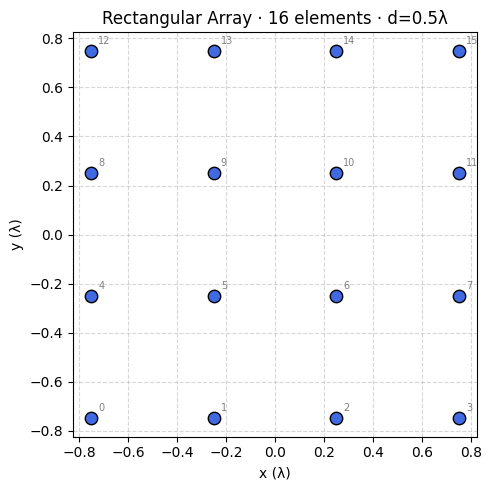

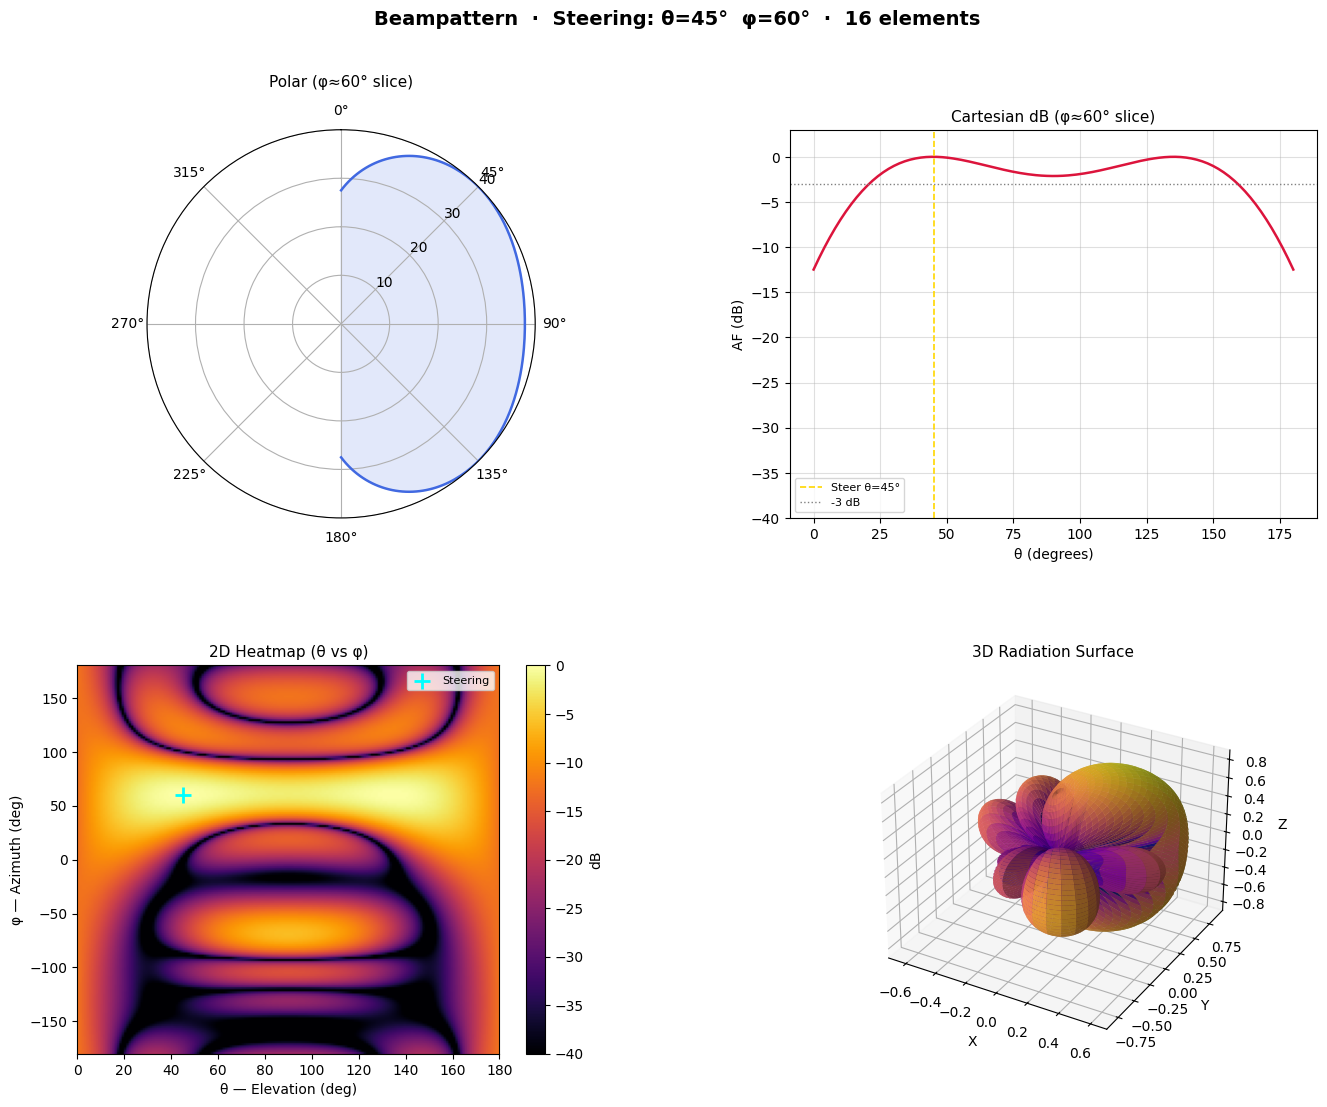

💾 Saved to /tmp/beampattern.png
──────────────────────────────────────────────────
  Array shape   : rectangular
  Elements      : 16
  Spacing       : 0.5 λ
  Window        : hamming
  Steering      : θ=45°  φ=60°
  3 dB Beamwidth: ~137.8°
  Peak          : 0.0 dB (normalized)
──────────────────────────────────────────────────


In [12]:
# ── Edit these parameters manually ─────────────────────────────────────────
CONFIG = dict(
    shape          = 'rectangular',  # 'rectangular' | 'circular' | 'hexagonal'
    N              = 16,           # number of microphones
    spacing_lambda = 0.5,          # element spacing in wavelengths
    window         = 'hamming',    # 'uniform' | 'hamming' | 'chebyshev'
    theta0_deg     = 45,           # steering elevation (0 = boresight)
    phi0_deg       = 60,           # steering azimuth
    dynamic_range_dB = 40,         # plot dynamic range in dB
)

run_simulation(**CONFIG)